## Customer Personality Analysis with Unsupervised Learning
### Abstract
This project explore unsupervised machine learning techniques for customer segmentation using a Kaggle dataset on marketing campagin. The aim is to find the meaningful customer clusters so that the information can be used in targeted marketing strategies. Two different clustering algorithms, K-Means clustering and DBSCAN, were applied to the raw data. The better model K Means was chosen as it better seperated customer groups and retrained using dimensionally reduced data via PCA. The two versions of the K Means model were then compared and contrasted via their silhouette score achieved at k=2. The results showed that PCA both simplified the data and enhanced the clustering results. 

### Data Explaination
The dataset used in this project comes from the Customer Personality Analysis dataset published on Kaggle, refer to the References section for more info. The dataset contains over 2,000 records and 29 different variables. Some of the variables were tranformed and standardized. For the most part, the data was well structured and relatively cleean which made it really easy to work with. 

### Codebook

| Variable Name                             | Type                          | Description                                                 |
| ----------------------------------------- | ----------------------------- | ----------------------------------------------------------- |
| `Income`                                  | Numeric                       | Yearly household income                                     |
| `Kidhome`                                 | Numeric                       | Number of children at home                                  |
| `Teenhome`                                | Numeric                       | Number of teenagers at home                                 |
| `Recency`                                 | Numeric                       | Days since last purchase                                    |
| `MntWines`                                | Numeric                       | Amount spent on wine                                        |
| `MntFruits`                               | Numeric                       | Amount spent on fruits                                      |
| `MntMeatProducts`                         | Numeric                       | Amount spent on meat                                        |
| `MntFishProducts`                         | Numeric                       | Amount spent on fish                                        |
| `MntSweetProducts`                        | Numeric                       | Amount spent on sweets                                      |
| `MntGoldProds`                            | Numeric                       | Amount spent on gold products                               |
| `NumDealsPurchases`                       | Numeric                       | Number of deals purchased                                   |
| `NumWebPurchases`                         | Numeric                       | Number of purchases made through the company’s website      |
| `NumCatalogPurchases`                     | Numeric                       | Number of catalog purchases                                 |
| `NumStorePurchases`                       | Numeric                       | Number of purchases made directly in stores                 |
| `NumWebVisitsMonth`                       | Numeric                       | Number of visits to the company’s website in the last month |
| `AcceptedCmp1`–`AcceptedCmp5`, `Response` | Binary                        | Whether the customer accepted each campaign                 |
| `Customer_Age`                            | Numeric                       | Calculated: 2024 - Year\_Birth                              |
| `Total_Spent`                             | Numeric                       | Total spending across all product categories                |
| `Education_*`, `Marital_Status_*`, etc.   | Categorical (One-hot encoded) | Encoded demographics                                        |


### Methodology/Procedures
The analysis began with downloading the data, importing the libraries, and importing the data into the Jupyter notebook. Next, the dataset was cleaned by dropping missing values, dropping irrelevant columns, and engineering features. Categorical variables were one-hot encoded and numerical features were standardized. Once all the previous steps were done, the data was ready to train the models. First two models were created, a K Means clustering algorithm and a DBSCAN algorithm and compared/contrasted. The two models were then visualized by using PCA to reduce the dimensions then using them for the plots to visually choose the better model. The elbow method using Silhouette scores were also viualized and the better model type was chosen. The better model, the K Means model was then retrained using reduced dimensions and compared to the original k model. Lastly, the best model was used to categorize customers, and the biggest differences between the clusters were visualized. 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

### Exploratory Data Analysis

In [2]:
# loading in the data & Exploratory Analysis
df = pd.read_csv("marketing_campaign.csv", sep="\t")
print(df.shape)
df.head()

(2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [4]:
# Data Cleaning & Preprocessing
df.dropna(inplace=True)
df.drop(columns=['ID'], inplace=True)

df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

# Perparing Features
df['Customer_Age'] = 2024 - df['Year_Birth']
df['Total_Spent'] = df[['MntWines', 'MntFruits', 'MntMeatProducts',
                        'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(axis=1)

df_model = df.drop(columns=['Year_Birth', 'Dt_Customer', 'Z_CostContact', 'Z_Revenue'])

# Encoding & Scaling
df_model = pd.get_dummies(df_model, drop_first=True)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)

k = 2 | Inertia = 64578.73 | Silhouette Score = 0.1973
k = 3 | Inertia = 61260.84 | Silhouette Score = 0.1616
k = 4 | Inertia = 58353.71 | Silhouette Score = 0.1245
k = 5 | Inertia = 56115.74 | Silhouette Score = 0.1221
k = 6 | Inertia = 54593.68 | Silhouette Score = 0.0905
k = 7 | Inertia = 53311.34 | Silhouette Score = 0.0876
k = 8 | Inertia = 52705.68 | Silhouette Score = 0.0956
k = 9 | Inertia = 50484.70 | Silhouette Score = 0.0990
k = 10 | Inertia = 48265.16 | Silhouette Score = 0.1016


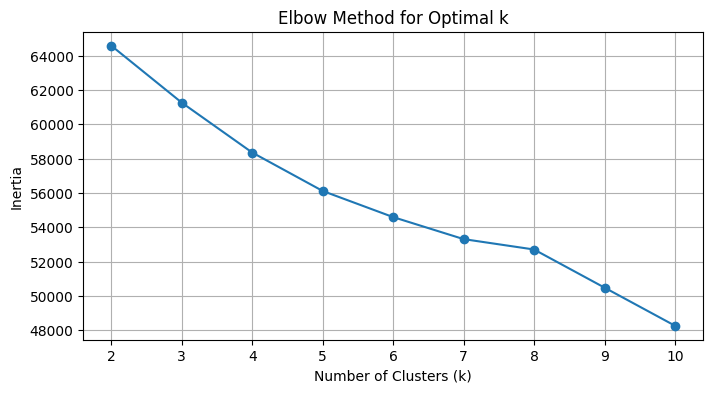

In [5]:
inertia = []
silhouette_scores = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"k = {k} | Inertia = {kmeans.inertia_:.2f} | Silhouette Score = {score:.4f}")

# Intertia Elbow Method
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

# Best K Means Model
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
df['KMeans_Cluster'] = kmeans_labels

In [6]:
# DBSCAN MODEL
dbscan = DBSCAN(eps=7, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)
df['DBSCAN_Cluster'] = dbscan_labels

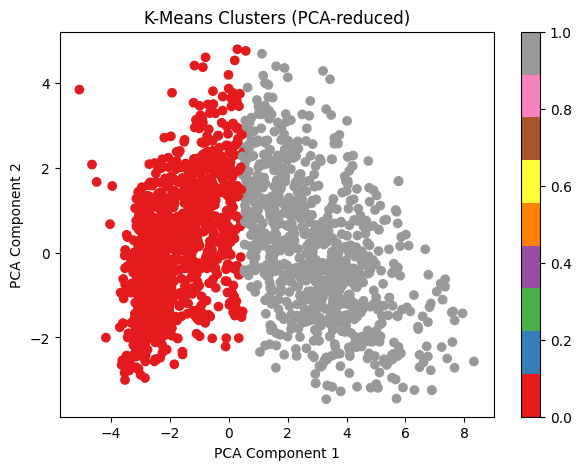

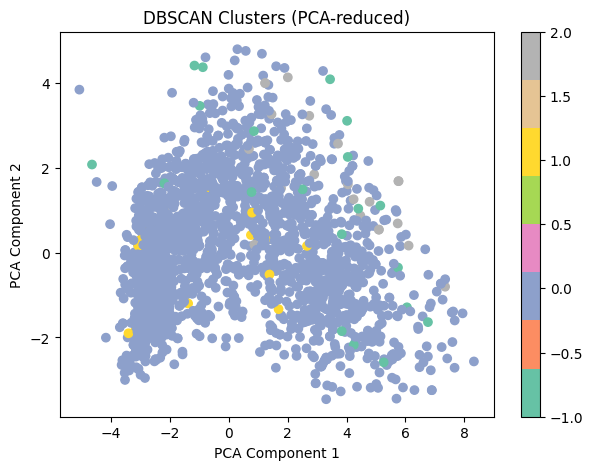

In [7]:
# PCA for plotting the clustering results
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# === VISUALIZE K-MEANS CLUSTERS ===
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='Set1')
plt.title('K-Means Clusters (PCA-reduced)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar()
plt.show()

# === VISUALIZE DBSCAN CLUSTERS ===
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='Set2')
plt.title('DBSCAN Clusters (PCA-reduced)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar()
plt.show()


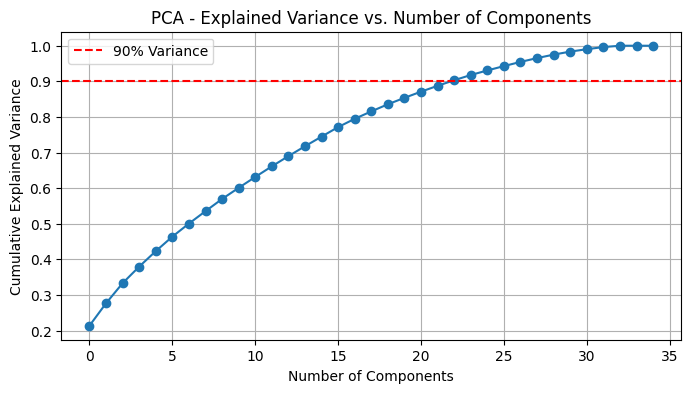

In [8]:
pca = PCA()
X_pca_full = pca.fit_transform(X_scaled)

# Plot cumulative explained variance
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Explained Variance vs. Number of Components')
plt.grid(True)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Variance')
plt.legend()
plt.show()

In [9]:
pca = PCA(n_components=22)
X_pca = pca.fit_transform(X_scaled)

# Elbow Method & Silhouette Scores
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    inertia.append(kmeans.inertia_)
    score = silhouette_score(X_pca, labels)
    silhouette_scores.append(score)
    print(f"k = {k} | Inertia = {kmeans.inertia_:.2f} | Silhouette Score = {score:.4f}")

# Final Model - KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X_pca)
df['KMeans_PCA_Cluster'] = kmeans_labels

k = 2 | Inertia = 55854.60 | Silhouette Score = 0.2133
k = 3 | Inertia = 52126.31 | Silhouette Score = 0.1451
k = 4 | Inertia = 50572.23 | Silhouette Score = 0.0738
k = 5 | Inertia = 48332.38 | Silhouette Score = 0.0754
k = 6 | Inertia = 45938.05 | Silhouette Score = 0.0844
k = 7 | Inertia = 43874.26 | Silhouette Score = 0.0900
k = 8 | Inertia = 43549.68 | Silhouette Score = 0.1125
k = 9 | Inertia = 42823.86 | Silhouette Score = 0.1009
k = 10 | Inertia = 40599.82 | Silhouette Score = 0.1048


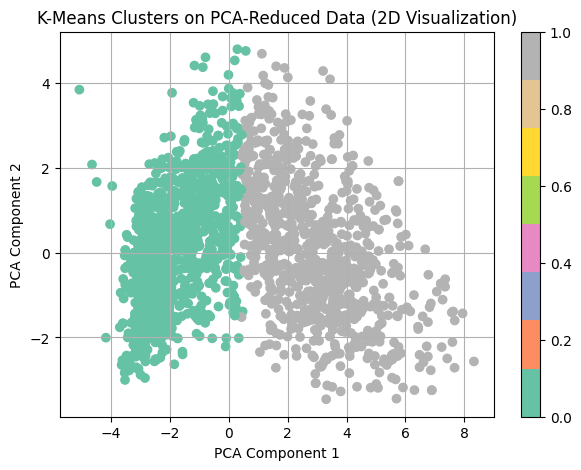

In [10]:
# Final Model Plot
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=kmeans_labels, cmap='Set2')
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("K-Means Clusters on PCA-Reduced Data (2D Visualization)")
plt.colorbar()
plt.grid(True)
plt.show()

In [11]:
df['Cluster'] = kmeans_labels

# Group by cluster and get mean values for original (unscaled) features
cluster_summary = df.groupby('Cluster').mean(numeric_only=True).T

# View the difference between the clusters
cluster_summary['Difference'] = cluster_summary[1] - cluster_summary[0]
cluster_summary.sort_values('Difference', ascending=False).head(10)

Cluster,0,1,Difference
Income,38982.537134,72272.012458,33289.475323
Total_Spent,185.500375,1243.496036,1057.995661
MntWines,101.785446,612.007928,510.222481
MntMeatProducts,37.486122,362.507361,325.021240
MntFishProducts,9.936234,79.456399,69.520165
MntGoldProds,22.441110,76.458664,54.017553
MntSweetProducts,6.976744,57.300113,50.323369
MntFruits,6.874719,55.765572,48.890853
NumStorePurchases,3.960990,8.578709,4.617719
NumCatalogPurchases,0.891973,5.356738,4.464765


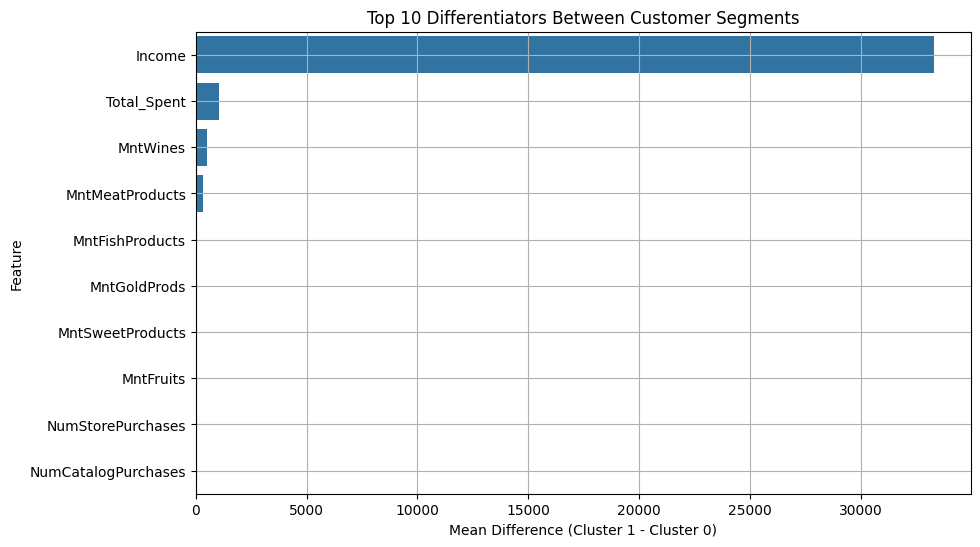

In [12]:
top_features = cluster_summary['Difference'].abs().sort_values(ascending=False).head(10).index.tolist()

plt.figure(figsize=(10, 6))
sns.barplot(x='Difference', y=cluster_summary.loc[top_features].index,
            data=cluster_summary.loc[top_features].reset_index())
plt.title("Top 10 Differentiators Between Customer Segments")
plt.xlabel("Mean Difference (Cluster 1 - Cluster 0)")
plt.ylabel("Feature")
plt.grid(True)
plt.show()

### Conclusion and Next Steps
The project successfully applied unsupervised learning techniques to segment customers with the available marketing data. Through good data cleaning, data preprocessing, feature engineering, dimension reduction via PCA, two different customer groups were uncovered. The K-Means clustering model outperformed DBSCAN and did even better after reducing the dimensions via PCA. Cluster 1 turned out to be higher spenders with a much higher invome on average, greater amount of expenditures, and more purchases in premium products such as meat, fish, and gold. These findings would be extremely beneficial in real world scenarios as they can drive marketing campaigns and store layouts. For example, meats and fish can be placed near to eachother along with gold relatively close in a store since customers that are likely to buy one are also more likely to buy from the other two categories. Also, marketing campaigns such as targetted advertisments can advertise these products to people who respond positively to at least one of them. 

This is work is by no means done; this data can be analyzed in so many more ways. For example, supervised learning models can be created to further predict how potential customers would respond by analyzing how all of the variables predict one of the existing variables already in the dataset. Clustering can also be extended to more granular levels by tracking this data over a longer time period. Further improvements in the modeling process would include adding different types of models in the analysis and trying different techniques. It would be interesting to see how these types of analysis would perform in an actual store as they provide very useful and actionable information. 

### References
Fernandes, S. (2022). Customer Personality Analysis [Data set]. Kaggle. https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis

scikit-learn developers. (2024). scikit-learn: Machine Learning in Python (Version 1.4.2) [Software documentation] https://scikit-learn.org/stable/index.html
